<a href="https://colab.research.google.com/github/joaoestella/IA-Course-Projects/blob/main/assignments/CP5_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício 1 / Exercise 1

### 🇧🇷 Português
Aplique os algoritmos de Clustering Aglomerativo e K-means no dataset Two Moons e gere um gráfico com o resultado obtido por cada método.

---

### 🇺🇸 English
Apply Agglomerative Clustering and K-means algorithms to the Two Moons dataset and generate a plot showing the results obtained by each method.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Configurações de estilo
sns.set(style="whitegrid")


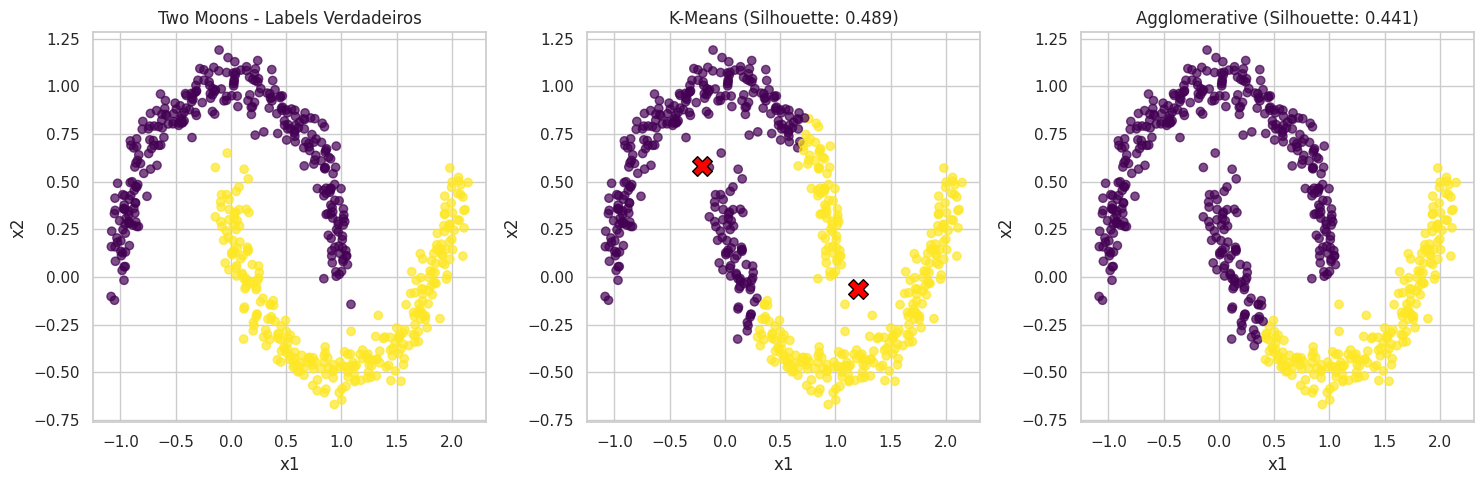

Silhouette Score K-Means: 0.489
Silhouette Score Agglomerative: 0.441
Observação: O K-Means tem dificuldades com formas não-convexas como as meias-luas.
O clustering aglomerativo pode ter melhor performance dependendo da métrica de linkage.


In [ ]:
# Aplicando K-Means no dataset Two Moons
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons)

# Aplicando Clustering Aglomerativo no dataset Two Moons
agg_moons = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_agg_moons = agg_moons.fit_predict(X_moons)

# Calculando métricas de avaliação
sil_kmeans_moons = silhouette_score(X_moons, labels_kmeans_moons)
sil_agg_moons = silhouette_score(X_moons, labels_agg_moons)

# Plotando os resultados
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dataset original
scatter1 = axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.7)
axes[0].set_title("Two Moons - Labels Verdadeiros")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

# K-Means
scatter2 = axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans_moons, cmap='viridis', alpha=0.7)
axes[1].scatter(kmeans_moons.cluster_centers_[:, 0], kmeans_moons.cluster_centers_[:, 1],
                marker='X', s=200, c='red', edgecolors='black')
axes[1].set_title(f"K-Means (Silhouette: {sil_kmeans_moons:.3f})")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

# Clustering Aglomerativo
scatter3 = axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_agg_moons, cmap='viridis', alpha=0.7)
axes[2].set_title(f"Agglomerative (Silhouette: {sil_agg_moons:.3f})")
axes[2].set_xlabel("x1")
axes[2].set_ylabel("x2")

plt.tight_layout()
plt.show()

print(f"Silhouette Score K-Means: {sil_kmeans_moons:.3f}")
print(f"Silhouette Score Agglomerative: {sil_agg_moons:.3f}")
print("Observação: O K-Means tem dificuldades com formas não-convexas como as meias-luas.")
print("O clustering aglomerativo pode ter melhor performance dependendo da métrica de linkage.")

# Exercício 2 / Exercise 2

### Segmentação de Imagens com K-Means

A ideia é tratar cada **pixel** como um ponto em um espaço de cores, por exemplo RGB, e aplicar K-Means para agrupar pixels com cores semelhantes. Em seguida, substituímos cada pixel pela cor média, centróide, de seu cluster, criando uma **imagem segmentada** que destaca regiões homogêneas.

### Exercício:
1. Carregar uma imagem, pode ser uma de demonstração; se `scikit-image` não estiver disponível, gerar uma imagem sintética.  
2. Converter a imagem para um espaço de cor apropriado, RGB ou Lab, e remodelar para `(n_pixels, n_canais)`.  
3. Executar `KMeans(n_clusters = k)`.  
4. Reconstruir e exibir a imagem segmentada.  
5. Isolar um cluster específico como máscara.  
6. Executar os itens 3 ao 5 para valores de K na faixa [10, 50, 200, 500, 1000].  

---

### Image Segmentation with K-Means

The idea is to treat each **pixel** as a point in a color space, for example RGB, and apply K-Means to group pixels with similar colors. Then, each pixel is replaced by the mean color, centroid, of its cluster, creating a **segmented image** that highlights homogeneous regions.

### Exercise:
1. Load an image, use a sample image; if `scikit-image` is not available, generate a synthetic image.  
2. Convert the image to an appropriate color space, RGB or Lab, and reshape it to `(n_pixels, n_channels)`.  
3. Run `KMeans(n_clusters = k)`.  
4. Reconstruct and display the segmented image.  
5. Isolate a specific cluster as a mask.  
6. Execute steps 3 to 5 for K values in the range [10, 50, 200, 500, 1000].  

Usando imagem real do scikit-image


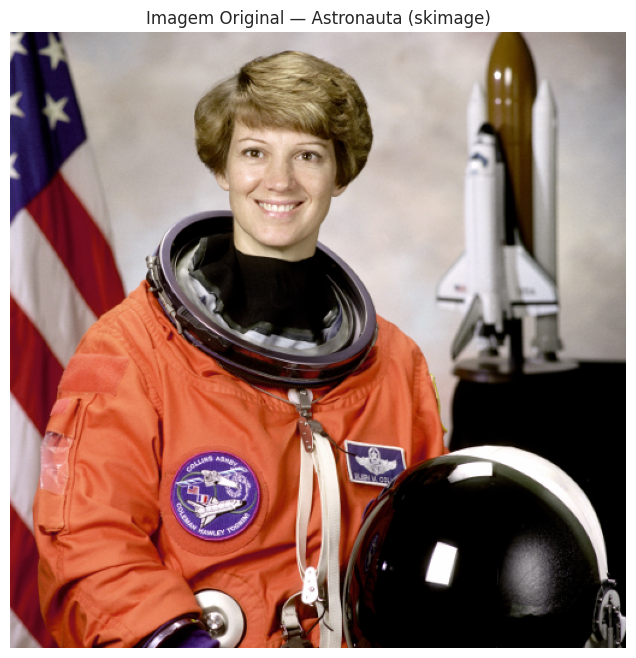

Processando segmentação com K=10...
Processando segmentação com K=50...
Processando segmentação com K=200...
Processando segmentação com K=500...
Processando segmentação com K=1000...


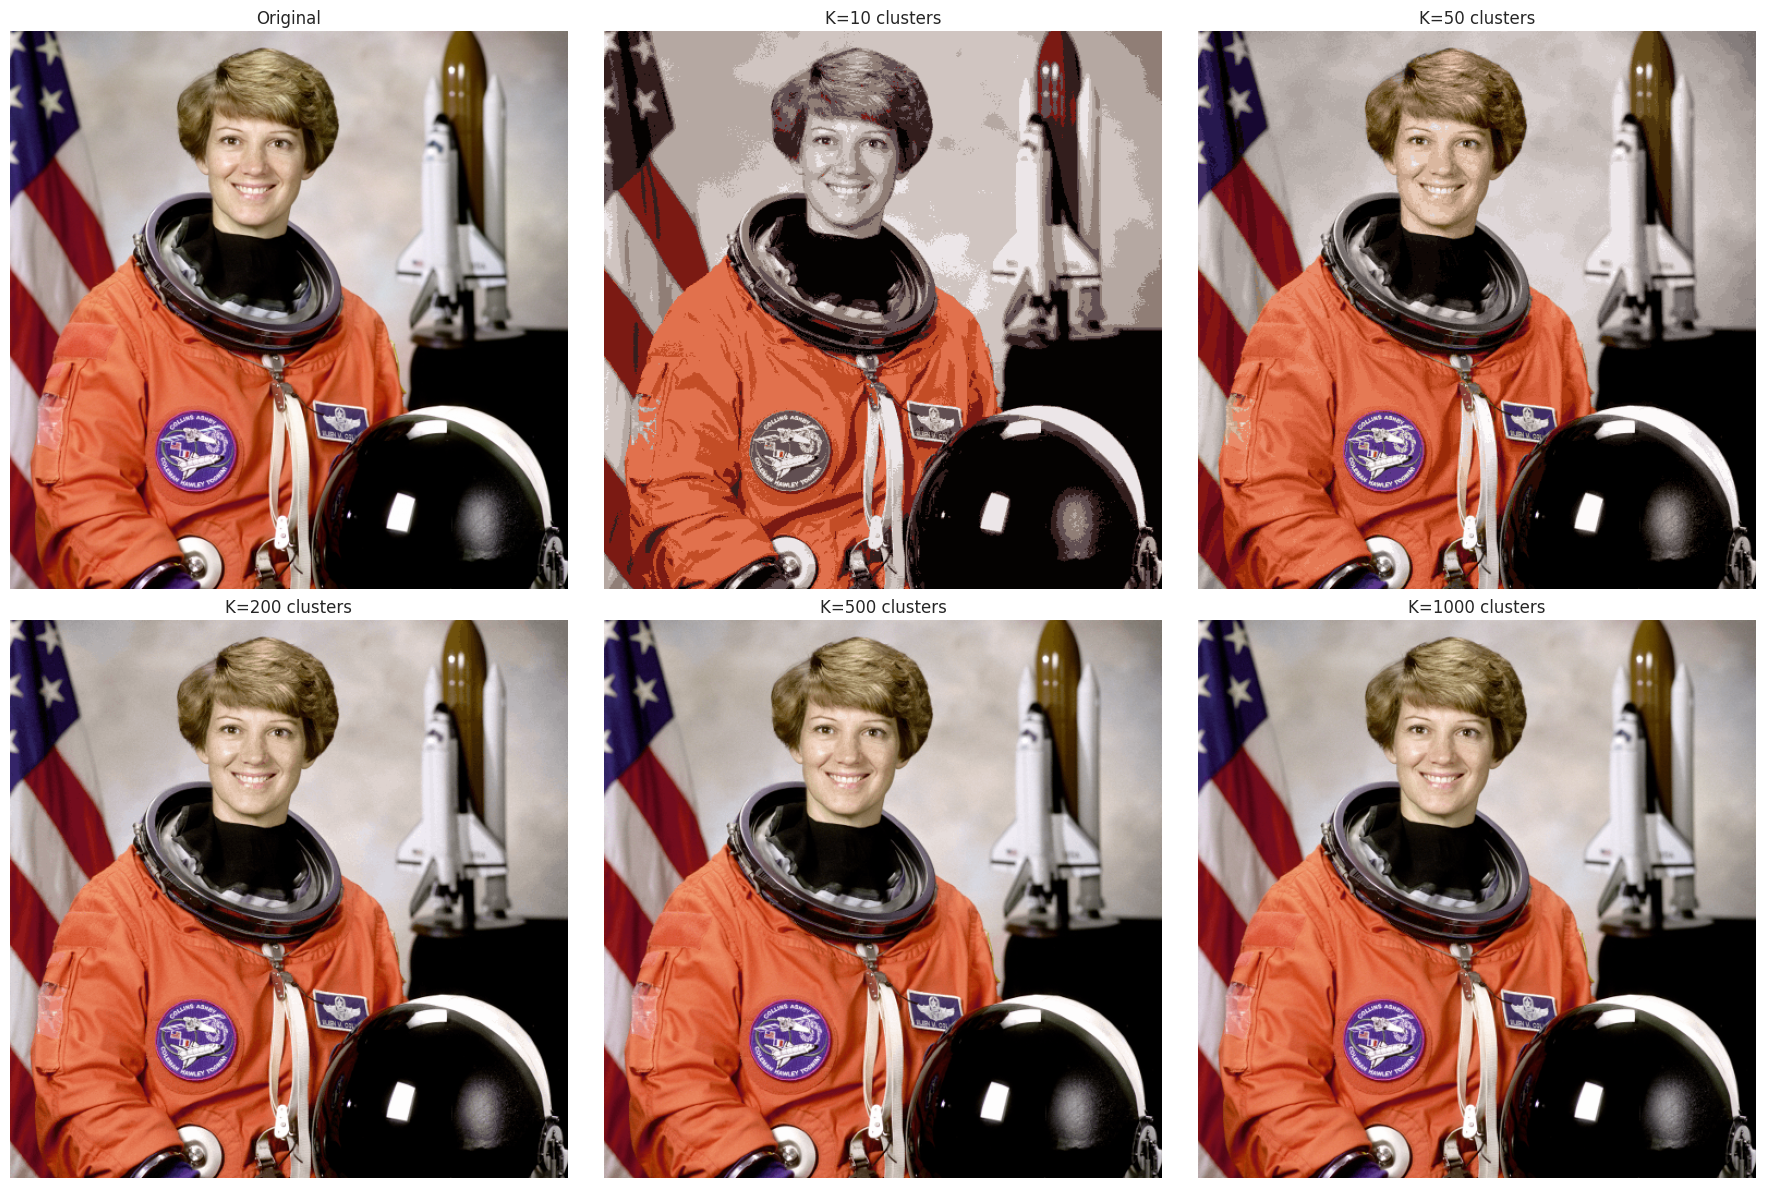


Demonstrando isolamento de cluster específico (K=10)...


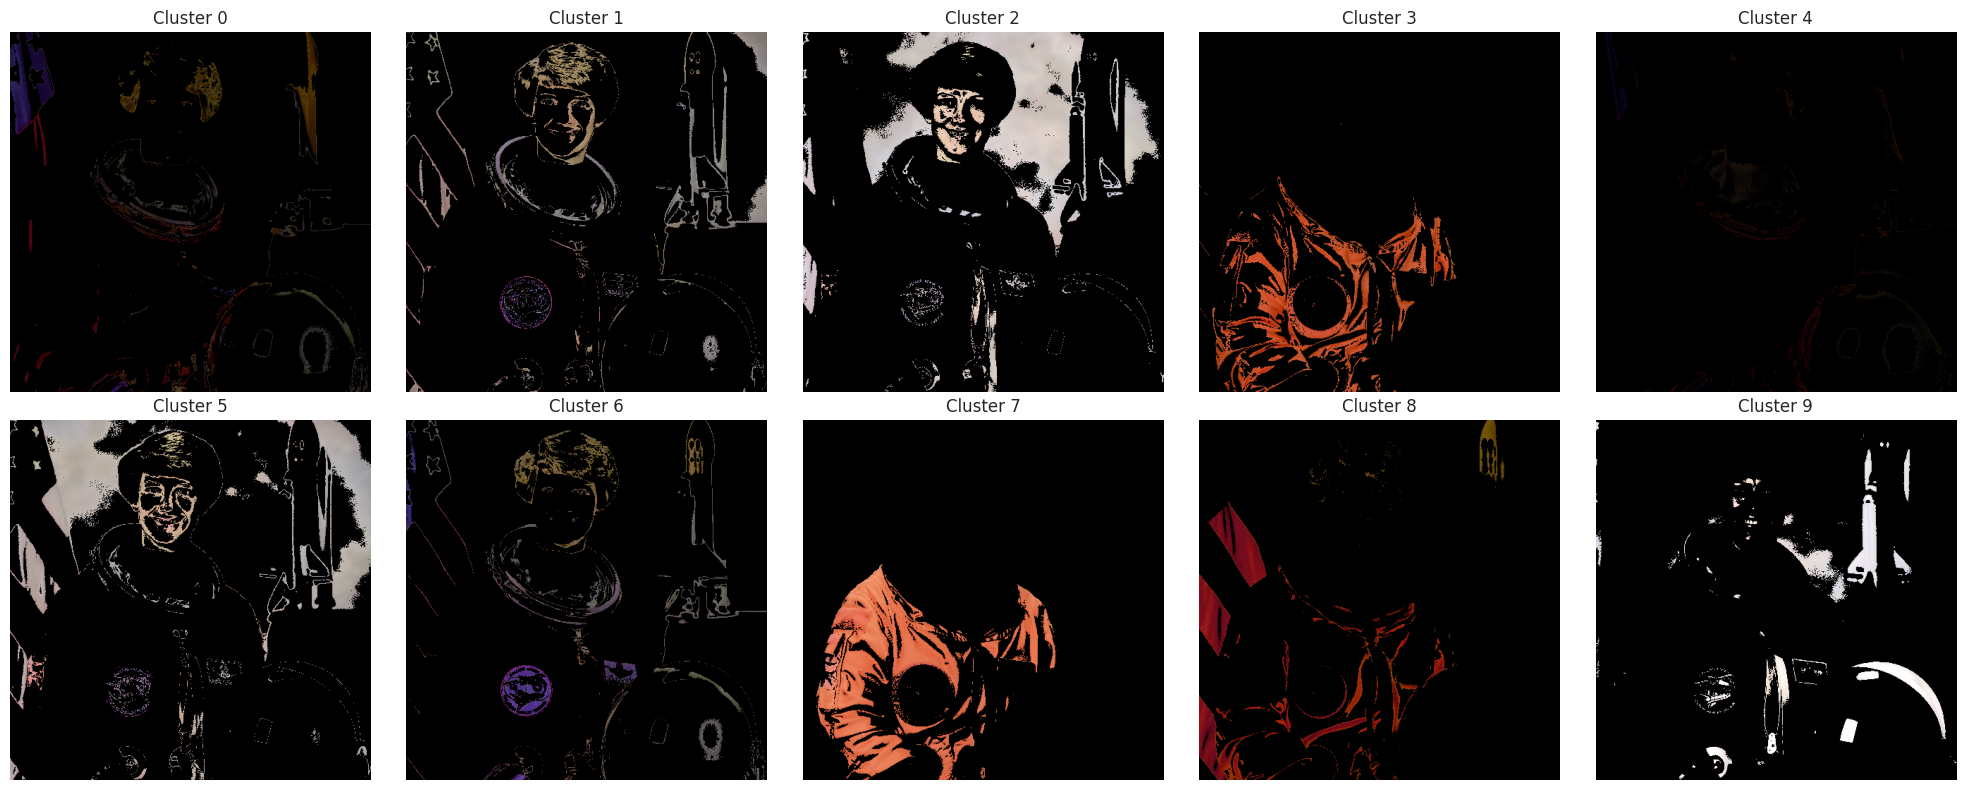


Análise das cores médias por cluster (K=10):
Cluster 0: RGB = (0.203, 0.121, 0.116)
Cluster 1: RGB = (0.565, 0.498, 0.464)
Cluster 2: RGB = (0.818, 0.775, 0.760)
Cluster 3: RGB = (0.767, 0.304, 0.153)
Cluster 4: RGB = (0.019, 0.009, 0.007)
Cluster 5: RGB = (0.711, 0.663, 0.639)
Cluster 6: RGB = (0.383, 0.310, 0.322)
Cluster 7: RGB = (0.883, 0.445, 0.305)
Cluster 8: RGB = (0.484, 0.102, 0.075)
Cluster 9: RGB = (0.928, 0.906, 0.911)


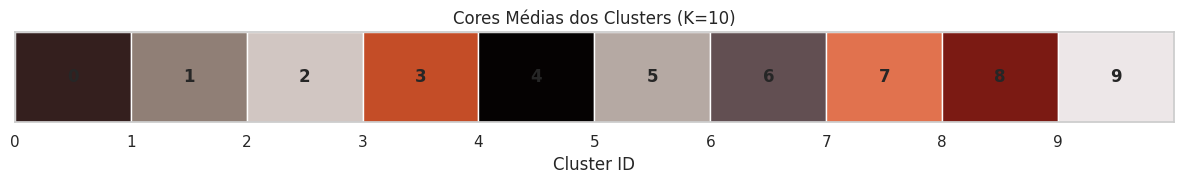

In [ ]:
# Tentando carregar a imagem
try:
    from skimage import data, img_as_float
    from skimage.color import rgb2lab, lab2rgb
    img = img_as_float(data.astronaut())  # (512, 512, 3) RGB
    img_name = "Astronauta (skimage)"
    print("Usando imagem real do scikit-image")
except ImportError:
    print("scikit-image não disponível. Criando imagem sintética...")
    # Criar uma imagem sintética colorida
    height, width = 200, 200
    img = np.zeros((height, width, 3))

    # Criar regiões coloridas
    img[:height//2, :width//2] = [0.8, 0.2, 0.2]  # Vermelho
    img[:height//2, width//2:] = [0.2, 0.8, 0.2]  # Verde
    img[height//2:, :width//2] = [0.2, 0.2, 0.8]  # Azul
    img[height//2:, width//2:] = [0.8, 0.8, 0.2]  # Amarelo

    # Adicionar ruído
    noise = np.random.normal(0, 0.1, img.shape)
    img = np.clip(img + noise, 0, 1)
    img_name = "Imagem Sintética"

# Exibir imagem original
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"Imagem Original — {img_name}")
plt.show()

def segmentar_imagem_kmeans(img, k):
    """
    Segmenta uma imagem usando K-Means - QUESTÃO 2
    """
    # Reshape da imagem para (n_pixels, n_channels)
    original_shape = img.shape
    img_reshaped = img.reshape(-1, img.shape[-1])

    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(img_reshaped)

    # Reconstruir imagem segmentada
    img_segmentada = kmeans.cluster_centers_[labels]
    img_segmentada = img_segmentada.reshape(original_shape)

    return img_segmentada, labels.reshape(original_shape[:2]), kmeans

# Valores de K para testar
valores_k = [10, 50, 200, 500, 1000]

# Criar visualização para diferentes valores de K
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Imagem original
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')

for i, k in enumerate(valores_k, 1):
    print(f"Processando segmentação com K={k}...")

    img_seg, labels, kmeans_model = segmentar_imagem_kmeans(img, k)

    axes[i].imshow(img_seg)
    axes[i].set_title(f"K={k} clusters")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Demonstração de isolamento de cluster específico
print("\nDemonstrando isolamento de cluster específico (K=10)...")
k_demo = 10
img_seg_demo, labels_demo, kmeans_demo = segmentar_imagem_kmeans(img, k_demo)

# Criar máscaras para diferentes clusters
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for cluster_id in range(k_demo):
    row = cluster_id // 5
    col = cluster_id % 5

    # Criar máscara para o cluster
    mask = (labels_demo == cluster_id)

    # Criar imagem isolada
    img_isolada = img.copy()
    img_isolada[~mask] = 0  # Pixels fora do cluster ficam pretos

    axes[row, col].imshow(img_isolada)
    axes[row, col].set_title(f"Cluster {cluster_id}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Análise da distribuição de cores por cluster
print("\nAnálise das cores médias por cluster (K=10):")
cores_medias = kmeans_demo.cluster_centers_
for i, cor in enumerate(cores_medias):
    print(f"Cluster {i}: RGB = ({cor[0]:.3f}, {cor[1]:.3f}, {cor[2]:.3f})")

# Visualização das cores médias
fig, ax = plt.subplots(1, 1, figsize=(12, 2))
for i, cor in enumerate(cores_medias):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=cor))
    ax.text(i+0.5, 0.5, f'{i}', ha='center', va='center', fontweight='bold')

ax.set_xlim(0, len(cores_medias))
ax.set_ylim(0, 1)
ax.set_title('Cores Médias dos Clusters (K=10)')
ax.set_xlabel('Cluster ID')
ax.set_xticks(range(len(cores_medias)))
ax.set_yticks([])
plt.tight_layout()
plt.show()

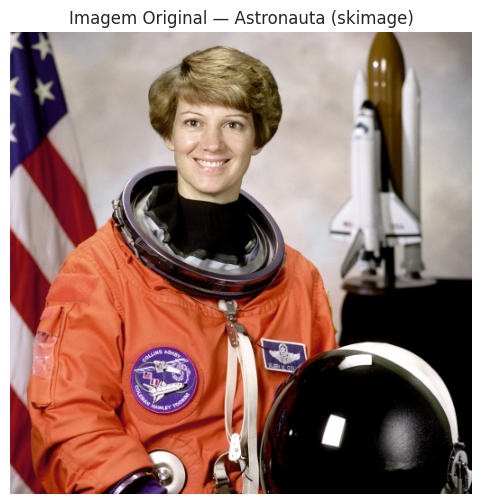

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Tentativa de carregar uma imagem de exemplo do scikit-image; se falhar, criaremos uma imagem sintética
img = None
img_name = None

from skimage import data, img_as_float
from skimage.color import rgb2lab, lab2rgb
img = img_as_float(data.astronaut())  # (512, 512, 3) RGB
img_name = "Astronauta (skimage)"

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Imagem Original — {img_name}")
plt.show()